# iris案例

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
iris = load_iris()
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [3]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [4]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [5]:
x,y = iris.data,iris.target

In [7]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)
knn_model = KNeighborsClassifier()
knn_model.fit(x_train,y_train)
print('训练集的准确率:',knn_model.score(x_train,y_train))
print('测试集的准确率:',knn_model.score(x_test,y_test))

训练集的准确率: 0.9583333333333334
测试集的准确率: 0.9666666666666667


In [11]:
# 从scikit-learn的模型选择模块导入GridSearchCV类
# GridSearchCV用于通过网格搜索的方式寻找模型的最优参数组合
from sklearn.model_selection import GridSearchCV

# 定义要搜索的n_neighbors参数范围：1到10的整数
# 这里使用tuple将range转换为元组，作为参数网格的候选值
n_neighbors = tuple(range(1,11))

# 创建GridSearchCV对象，配置网格搜索参数
# estimator=KNeighborsClassifier()：指定要优化的基础模型为K近邻分类器
# param_grid={'n_neighbors':n_neighbors}：指定要搜索的参数网格，这里只搜索n_neighbors参数
# cv=5：指定使用5折交叉验证来评估参数性能
cv = GridSearchCV(estimator=KNeighborsClassifier(),
                  param_grid={'n_neighbors':n_neighbors},
                  cv =5 )

# 执行网格搜索，使用训练数据x和标签y进行模型训练和参数优化
# 这一步会自动为每种参数组合进行交叉验证，并计算性能评分
cv.fit(x,y)

# 输出找到的最优参数组合
# best_params_属性会返回在交叉验证中表现最好的参数值
cv.best_params_

{'n_neighbors': 6}

In [10]:
knn_model = KNeighborsClassifier(n_neighbors=6)
knn_model.fit(x_train,y_train)
print('训练集的准确率:',knn_model.score(x_train,y_train))
print('测试集的准确率:',knn_model.score(x_test,y_test))

训练集的准确率: 0.95
测试集的准确率: 1.0


# 机器学习的简单策略

In [1]:
import pandas as pd
import pandas_datareader.data as web
import numpy as np

In [9]:
import pandas as pd
import tushare as ts  # 导入tushare

# 1. 初始化tushare（替换为你的Token）
ts.set_token("598eb3c437b4143dde41a08f283e909b5cce0154bb923c346d4c6e58")  # 示例：ts.set_token("abc123def456...")
pro = ts.pro_api()

def load_stock(start_date, end_date, outputfile, stock_code):
    try:
        # 尝试读取本地已保存的pickle文件
        df = pd.read_pickle(outputfile)
        print(f"成功读取本地文件：{outputfile}")
    except FileNotFoundError:
        print(f"本地文件不存在，从tushare下载 {stock_code} 数据...")
        
        # 2. 调用tushare接口获取A股日线数据（注意：tushare日期格式为YYYYMMDD）
        # 股票代码无需加.SS，直接传6位数字（如601318）
        df = pro.daily(
            ts_code=stock_code,  # A股代码格式：601318.SH（沪市）/000001.SZ（深市）
            start_date=start_date.replace("-", ""),  # 转换为YYYYMMDD（如20170309）
            end_date=end_date.replace("-", "")       # 转换为YYYYMMDD（如20200305）
        )
        
        # 3. 数据格式调整（tushare返回的列名与Yahoo不同，可按需重命名）
        # 重命名列：tushare列名 → 常用列名（如open=开盘价，close=收盘价）
        df.rename(columns={
            "open": "Open", 
            "high": "High", 
            "low": "Low", 
            "close": "Close", 
            "vol": "Volume"  # 成交量
        }, inplace=True)
        
        # 4. 保存为pickle文件，方便下次使用
        df.to_pickle(outputfile)
        print(f"数据下载完成，已保存为：{outputfile}")
    
    return df

# 调用函数（注意：tushare的A股代码格式为「6位数字.SH（沪市）」或「6位数字.SZ（深市）」）
zgpa = load_stock(
    start_date="2017-03-09",
    end_date="2020-03-05",
    outputfile="601318.pkl",
    stock_code="601318.SH"  # 601318是中国光大银行，沪市股票，后缀用.SH
)

# 查看数据前5行，验证是否成功
print("\n数据预览：")
#print('是否存在空值',all(pd.isnull(zgpa['trade_date'])))
zgpa['trade_date'] = pd.to_datetime(zgpa['trade_date'].astype(str), format='%Y%m%d')
zgpa.set_index('trade_date',inplace = True)
zgpa

成功读取本地文件：601318.pkl

数据预览：


,ts_code,Open,High,Low,Close,pre_close,change,pct_chg,Volume,amount
trade_date,,,,,,,,,,
2020-03-05,601318.SH,81.01,82.76,80.62,82.45,80.58,1.87,2.3207,960642.71,7866801.864
2020-03-04,601318.SH,79.90,80.75,79.90,80.58,79.49,1.09,1.3712,677574.56,5443423.591
2020-03-03,601318.SH,80.48,80.57,79.26,79.49,79.58,-0.09,-0.1131,678238.40,5418803.178
2020-03-02,601318.SH,78.32,80.20,78.32,79.58,77.72,1.86,2.3932,712323.40,5669190.141
2020-02-28,601318.SH,78.60,79.29,77.71,77.72,79.79,-2.07,-2.5943,983923.14,7697148.541
...,...,...,...,...,...,...,...,...,...,...
2017-03-15,601318.SH,35.88,36.00,35.76,35.96,35.94,0.02,0.0600,268720.50,964386.172
2017-03-14,601318.SH,35.99,36.13,35.81,35.94,35.97,-0.03,-0.0800,276964.20,995908.965
2017-03-13,601318.SH,35.60,36.04,35.56,35.97,35.60,0.37,1.0400,359990.02,1291416.185


In [10]:
def classification_tc(df):
    """构建分类任务的特征和目标变量
    目标：预测下一天收盘价是否上涨（1表示上涨，-1表示下跌）
    """
    # 复制原数据以避免修改原始DataFrame
    df_copy = df.copy()
    
    # 计算开盘价与收盘价的差值
    df_copy['o_c'] = df_copy['Open'] - df_copy['Close']
    # 计算最高价与最低价的差值
    df_copy['h_l'] = df_copy['High'] - df_copy['Low']
    # 目标变量：下一天收盘价 > 当前收盘价则为1，否则为-1
    df_copy['target'] = np.where(df_copy['Close'].shift(-1) > df_copy['Close'], 1, -1)
    # 删除包含缺失值的行（最后一行因shift(-1)会产生NaN）
    df_copy = df_copy.dropna()
    
    # 特征变量
    x = df_copy[['o_c', 'h_l']]
    # 目标变量
    y = df_copy['target']
    
    return x, y, df_copy  # 同时返回特征、目标变量和处理后的DataFrame

def regression_tc(df):
    """构建回归任务的特征和目标变量
    目标：预测下一天收盘价与当前收盘价的差值
    """
    df_copy = df.copy()
    df_copy['o_c'] = df_copy['Open'] - df_copy['Close']
    df_copy['h_l'] = df_copy['High'] - df_copy['Low']
    # 目标变量：下一天收盘价与当前收盘价的差值
    df_copy['target'] = df_copy['Close'].shift(-1) - df_copy['Close']
    df_copy = df_copy.dropna()
    x = df_copy[['o_c', 'h_l']]
    y = df_copy['target']
    return x, y, df_copy

In [12]:
# 调用分类任务函数（现在返回三个值：x, y和处理后的df）
x, y, df= classification_tc(zgpa)

# 划分训练集和测试集（测试集占比20%）
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=0  # 固定random_state确保结果可复现
)

# 验证数据形状
print(f"训练集特征形状: {x_train.shape}")
print(f"测试集特征形状: {x_test.shape}")
print(f"训练集目标形状: {y_train.shape}")
print(f"测试集目标形状: {y_test.shape}")

# 初始化并训练KNN模型
model_knn = KNeighborsClassifier()
model_knn.fit(x_train, y_train)

# 评估模型性能
print('\nKNN在训练集的准确率:', model_knn.score(x_train, y_train))
print('KNN在测试集的准确率:', model_knn.score(x_test, y_test))

# 使用KNN模型预测每日股票涨跌
df['Predict_Signal'] = model_knn.predict(x)

# 计算每日收益率（对数收益率）
df['Return'] = np.log(df['Close'] / df['Close'].shift(1))

# 查看处理后的数据
print('\n处理后的数据预览：')
df.head()

训练集特征形状: (583, 2)
测试集特征形状: (146, 2)
训练集目标形状: (583,)
测试集目标形状: (146,)

KNN在训练集的准确率: 0.855917667238422
KNN在测试集的准确率: 0.815068493150685

处理后的数据预览：


,ts_code,Open,High,Low,Close,pre_close,change,pct_chg,Volume,amount,o_c,h_l,target,Predict_Signal,Return
trade_date,,,,,,,,,,,,,,,
2020-03-05,601318.SH,81.01,82.76,80.62,82.45,80.58,1.87,2.3207,960642.71,7866801.864,-1.44,2.14,-1,-1,NaN
2020-03-04,601318.SH,79.90,80.75,79.90,80.58,79.49,1.09,1.3712,677574.56,5443423.591,-0.68,0.85,-1,-1,-0.022942
2020-03-03,601318.SH,80.48,80.57,79.26,79.49,79.58,-0.09,-0.1131,678238.40,5418803.178,0.99,1.31,1,1,-0.013619
2020-03-02,601318.SH,78.32,80.20,78.32,79.58,77.72,1.86,2.3932,712323.40,5669190.141,-1.26,1.88,-1,-1,0.001132
2020-02-28,601318.SH,78.60,79.29,77.71,77.72,79.79,-2.07,-2.5943,983923.14,7697148.541,0.88,1.58,1,1,-0.023650


In [13]:
def cum_return(df, split_value):
    """计算指定区间的累计收益率
    
    参数:
        df: 包含'Return'列的DataFrame
        split_value: 用于切片的索引值，取split_value之后的数据计算
        
    返回:
        累计收益率（乘以100转为百分比）
    """
    # 使用split_value作为索引切片，取之后的数据计算累计收益
    cum_returns = df[split_value:]['Return'].cumsum() * 100
    return cum_returns

def strategy_return(df, split_value):
    """计算策略的累计收益率
    
    参数:
        df: 包含'Return'和'Predict_Signal'列的DataFrame
        split_value: 用于切片的索引值，取split_value之后的数据计算
        
    返回:
        策略累计收益率（乘以100转为百分比）
    """
    # 计算策略收益率 = 每日收益率 * 前一天的预测信号
    df['Strategy_return'] = df['Return'] * df['Predict_Signal'].shift(1)
    # 计算指定区间的累计策略收益率
    cum_strategy_return = df[split_value:]['Strategy_return'].cumsum() * 100
    return cum_strategy_return
def plot_chart(cum_return,cum_strategy_return,symbol):
    plt.figure(figsize=(10,8))
    plt.plot(cum_return,'--',label = '%s Returns ' %symbol)
    plt.plot(cum_strategy_return,label = 'Strategy')
    plt.legend()
    plt.show()

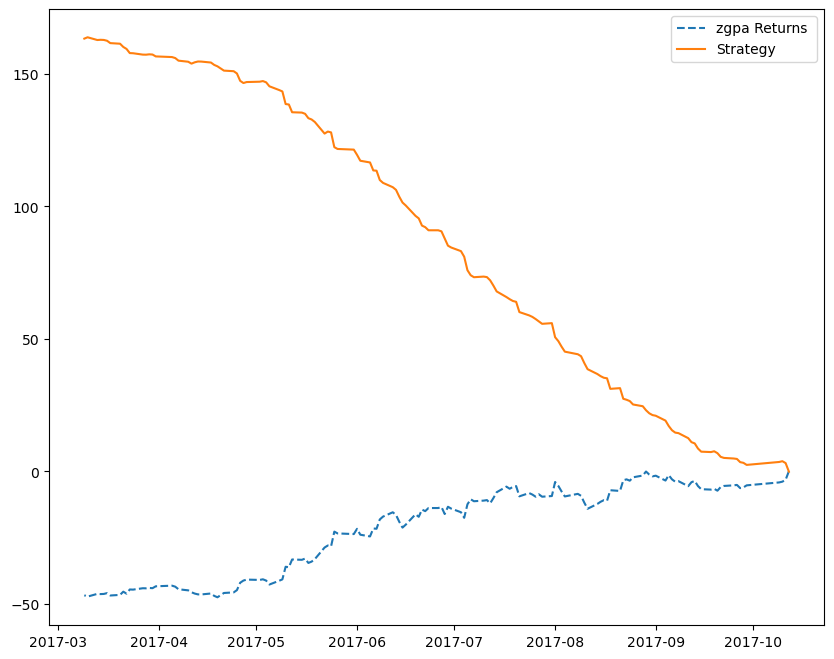

In [14]:
cum_return = cum_return(df,split_value=len(x_train))
cum_strategy_return = strategy_return(df,split_value=len(x_train))
plot_chart(cum_return,cum_strategy_return,'zgpa')

训练集特征形状: (576, 2)
测试集特征形状: (145, 2)
训练集目标形状: (576,)
测试集目标形状: (145,)

KNN在训练集的R²分数: 0.7528421250897134
KNN在测试集的R²分数: 0.8110853824240175

策略表现概览：
总基准收益率: -77.07%
总策略收益率: 52.55%
超额收益率: 129.62%


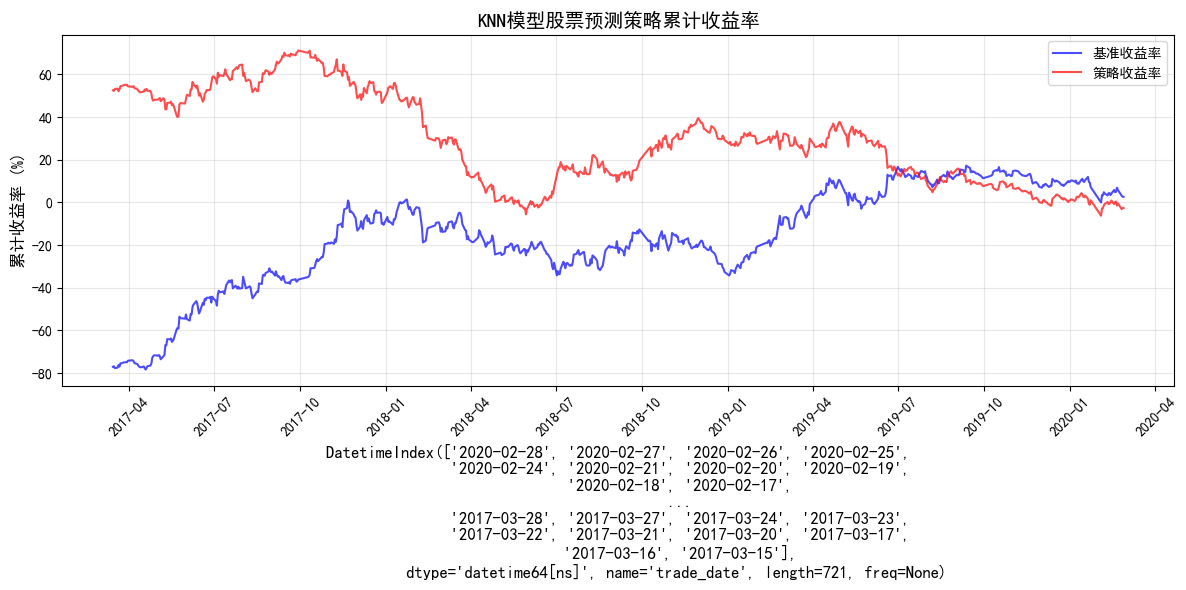

In [18]:
from sklearn.neighbors  import KNeighborsRegressor
import matplotlib.dates as mdates
# 调用回归任务函数（现在返回三个值：x, y和处理后的df）
x, y, df= regression_tc(df)
# 划分训练集和测试集（测试集占比20%）
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=0  # 固定random_state确保结果可复现
)

# 验证数据形状
print(f"训练集特征形状: {x_train.shape}")
print(f"测试集特征形状: {x_test.shape}")
print(f"训练集目标形状: {y_train.shape}")
print(f"测试集目标形状: {y_test.shape}")

# 初始化并训练KNN模型
model_knn = KNeighborsRegressor()
model_knn.fit(x_train, y_train)

# 评估模型性能
print('\nKNN在训练集的R²分数:', model_knn.score(x_train, y_train))
print('KNN在测试集的R²分数:', model_knn.score(x_test, y_test))
# 使用KNN模型预测
df['Predict_Signal'] = model_knn.predict(x)

# 计算每日收益率（对数收益率）
df['Return'] = np.log(df['Close'] / df['Close'].shift(1))

# 生成交易信号：根据预测值确定买卖方向
# 这里假设预测值为正表示上涨，应买入；为负表示下跌，应卖出
df['Position'] = np.where(df['Predict_Signal'] > 0, 1, -1)

# 计算策略收益率（根据信号调整的收益率）
df['Strategy_Return'] = df['Position'] * df['Return']

# 计算累计收益率（策略和基准）
df['Cumulative_Market_Return'] = df['Return'].cumsum() * 100  # 基准（买入持有）
df['Cumulative_Strategy_Return'] = df['Strategy_Return'].cumsum() * 100  # 策略

# 输出策略表现
print("\n策略表现概览：")
print(f"总基准收益率: {df['Cumulative_Market_Return'].iloc[-1]:.2f}%")
print(f"总策略收益率: {df['Cumulative_Strategy_Return'].iloc[-1]:.2f}%")
print(f"超额收益率: {df['Cumulative_Strategy_Return'].iloc[-1] - df['Cumulative_Market_Return'].iloc[-1]:.2f}%")
plt.rcParams['font.family'] = ['SimHei']  # 解决中文显示乱码
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示异常
# 可视化累计收益率
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Cumulative_Market_Return'], label='基准收益率', color='blue', alpha=0.7)
plt.plot(df.index, df['Cumulative_Strategy_Return'], label='策略收益率', color='red', alpha=0.7)

# 设置图表属性
plt.title('KNN模型股票预测策略累计收益率', fontsize=14)
plt.xlabel(df.index, fontsize=12)
plt.ylabel('累计收益率 (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# 美化x轴日期显示
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()